In [1]:
import pandas as pd
import numpy as np
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn.ensemble import RandomForestRegressor
# from sklearn.preprocessing import StandardScaler
from sklearn.metrics import mean_absolute_error, mean_absolute_percentage_error, root_mean_squared_error, r2_score

import xgboost as xgb

In [2]:
# Load the data from the CSV file
df = pd.read_csv("../data/clean/data.csv")

# Display the first few rows to verify the data was loaded correctly
df.head(1)

,propertyId,postalCode,typeOfProperty,subtypeOfProperty,price,typeOfSale,numberOfRooms,livingArea,equippedKitchen,furnished,...,hasHeatPump,hasPhotovoltaicPanels,hasThermicPanels,hasDoubleGlazing,epcScore,primaryEnergyConsumptionPerSqm,renovationObligation,cadastralIncome,parkingCountIndoor,parkingCountOutdoor
0,11218487,8300,1,1,1295000,0,1,64.0,-1,0,...,-1,0,0,1,-1,-1,-1,-1,0,0


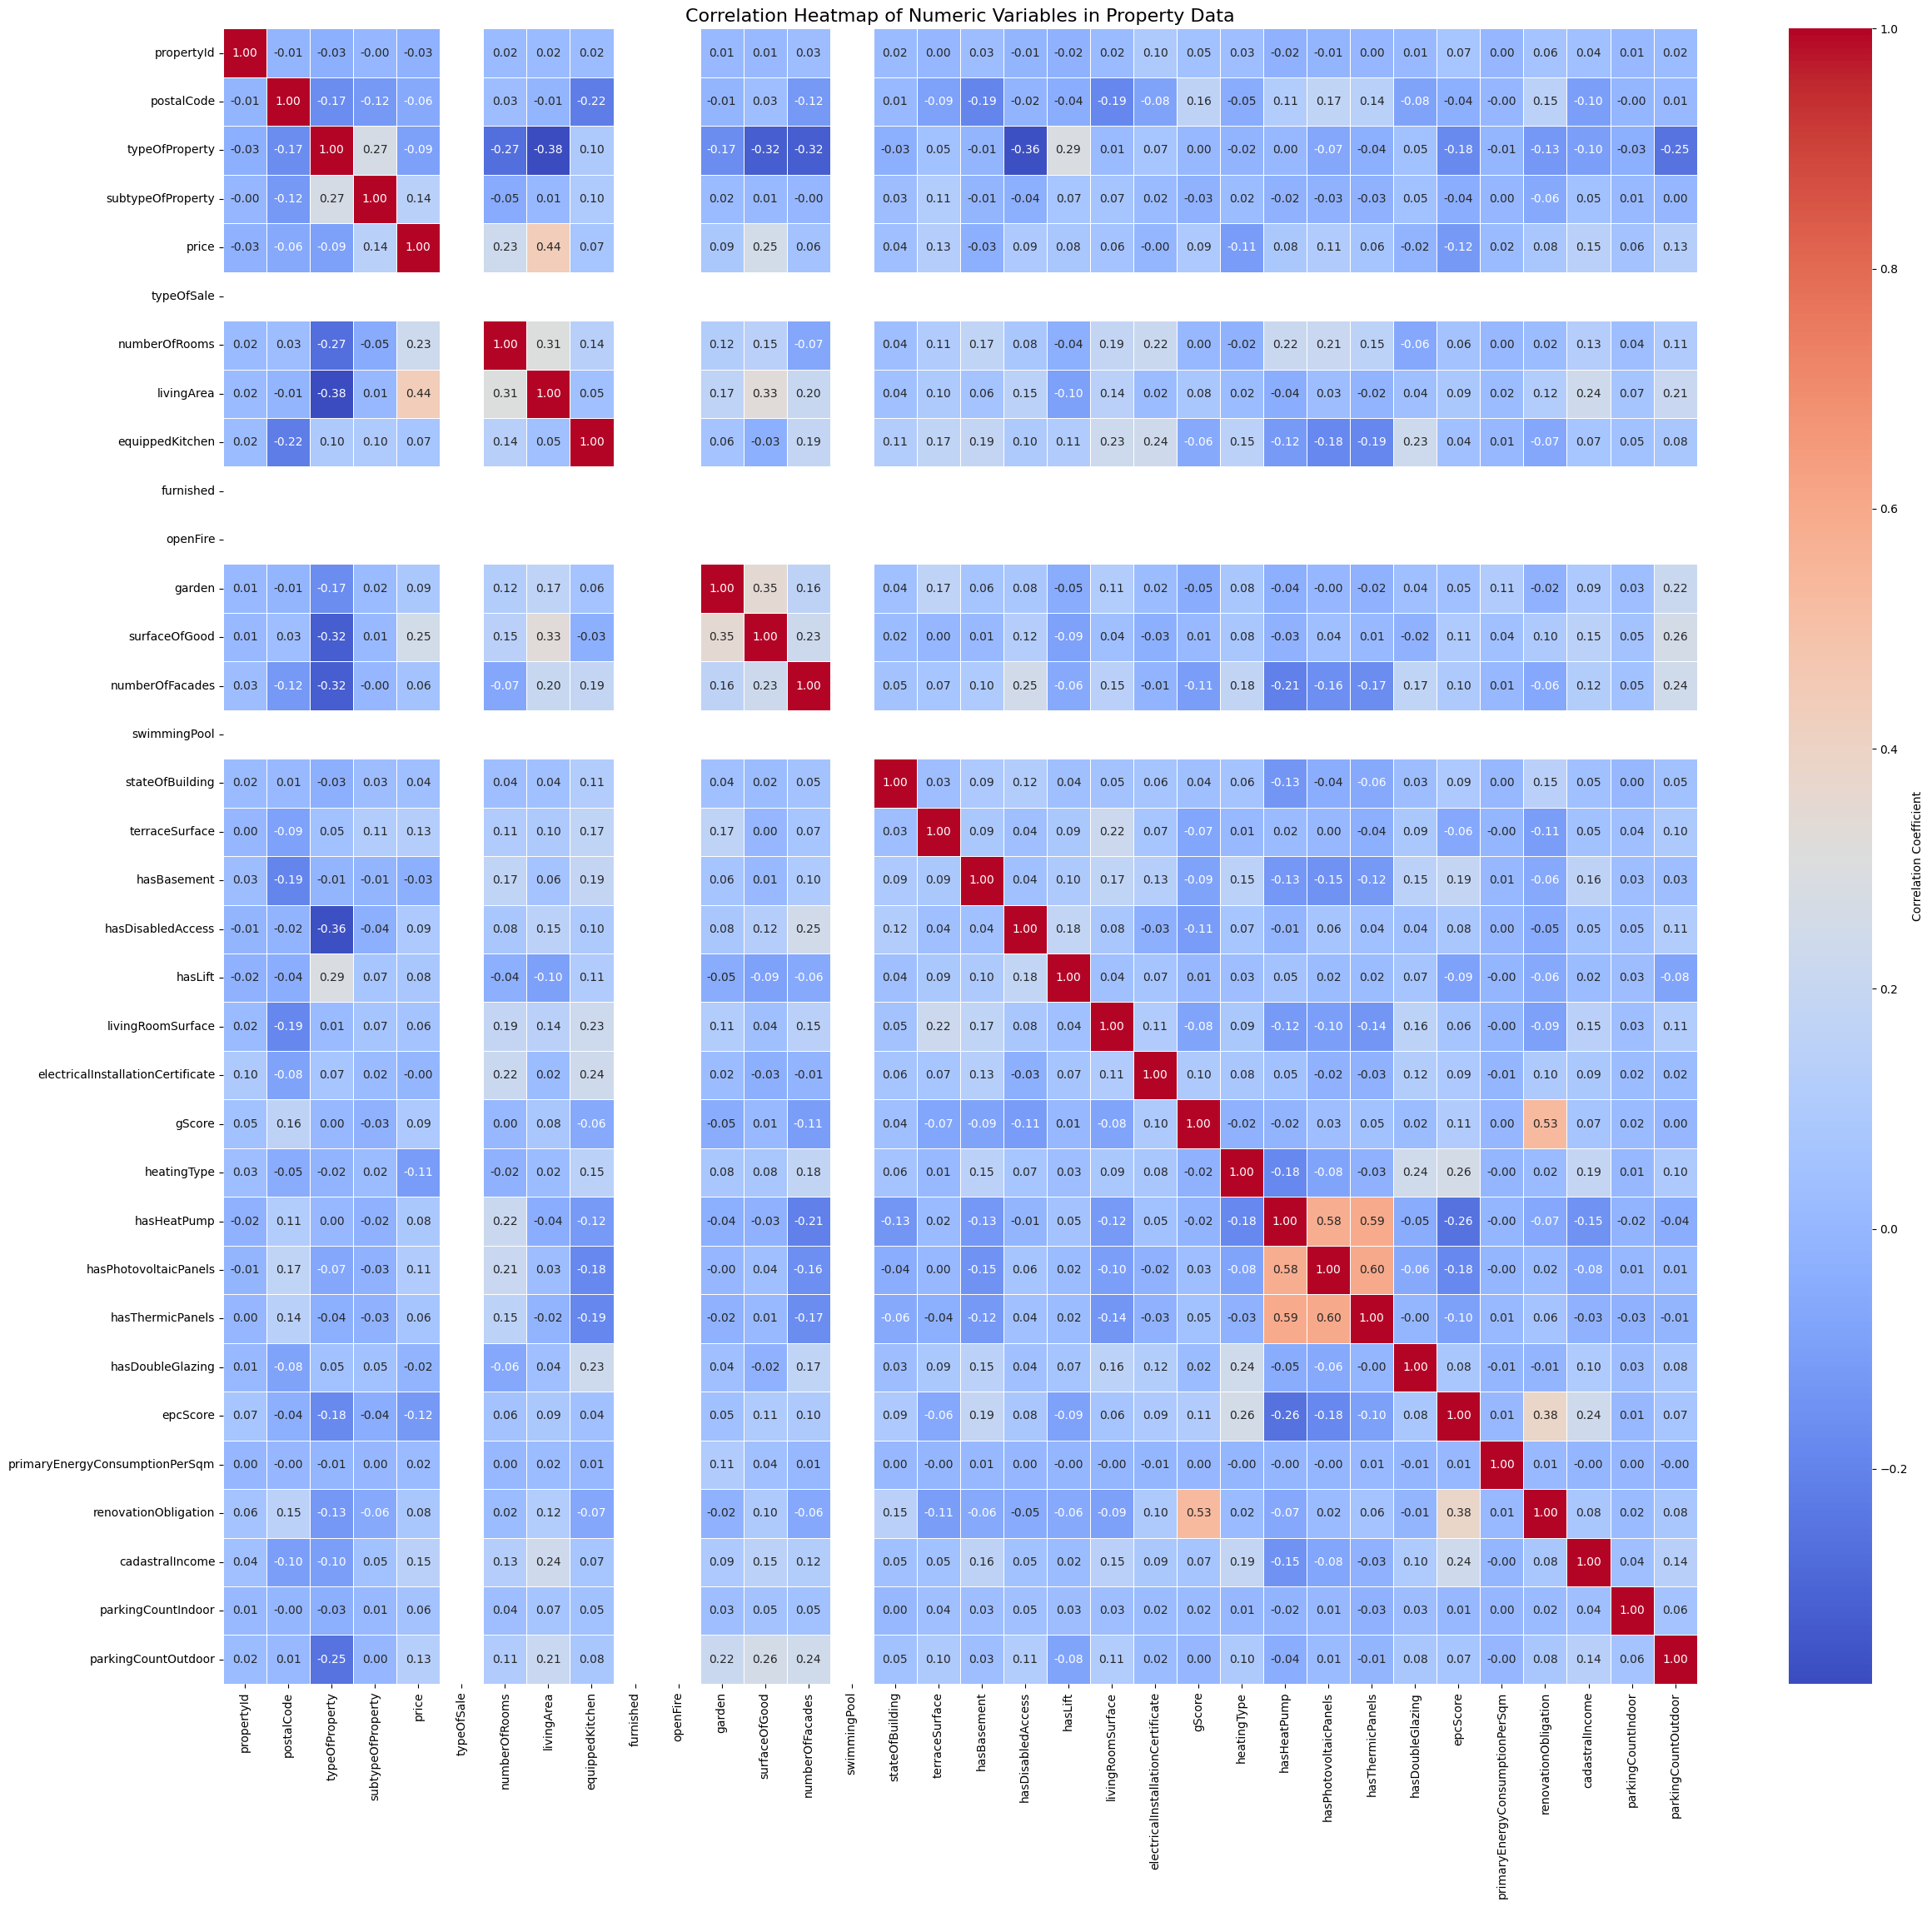

In [13]:
# Calculate the correlation matrix, excluding propertyId
# Calculate the correlation matrix, selecting only numeric columns to avoid errors
from matplotlib import pyplot as plt
import seaborn as sns


correlation_matrix = df.select_dtypes(include=['int64', 'float64']).corr()

# Create a figure with appropriate size
plt.figure(figsize=(25, 23))

# Create a heatmap with value labels
heatmap = sns.heatmap(
    correlation_matrix, 
    annot=True,  # Show values on the heatmap
    cmap='coolwarm',  # Color map
    fmt='.2f',  # Format for the annotations (2 decimal places)
    linewidths=0.5,  # Width of the lines that divide each cell
    cbar_kws={'label': 'Correlation Coefficient'}  # Colorbar label
)

# Set title
plt.title('Correlation Heatmap of Numeric Variables in Property Data', fontsize=16)

# Adjust layout
plt.tight_layout()

# Display the heatmap
plt.show()

d:\BeCode\becode_projects\scraping-immoeliza-giraffe\.venv\Lib\site-packages\numpy\lib\_function_base_impl.py:3045: RuntimeWarning: invalid value encountered in divide
  c /= stddev[:, None]
d:\BeCode\becode_projects\scraping-immoeliza-giraffe\.venv\Lib\site-packages\numpy\lib\_function_base_impl.py:3046: RuntimeWarning: invalid value encountered in divide
  c /= stddev[None, :]


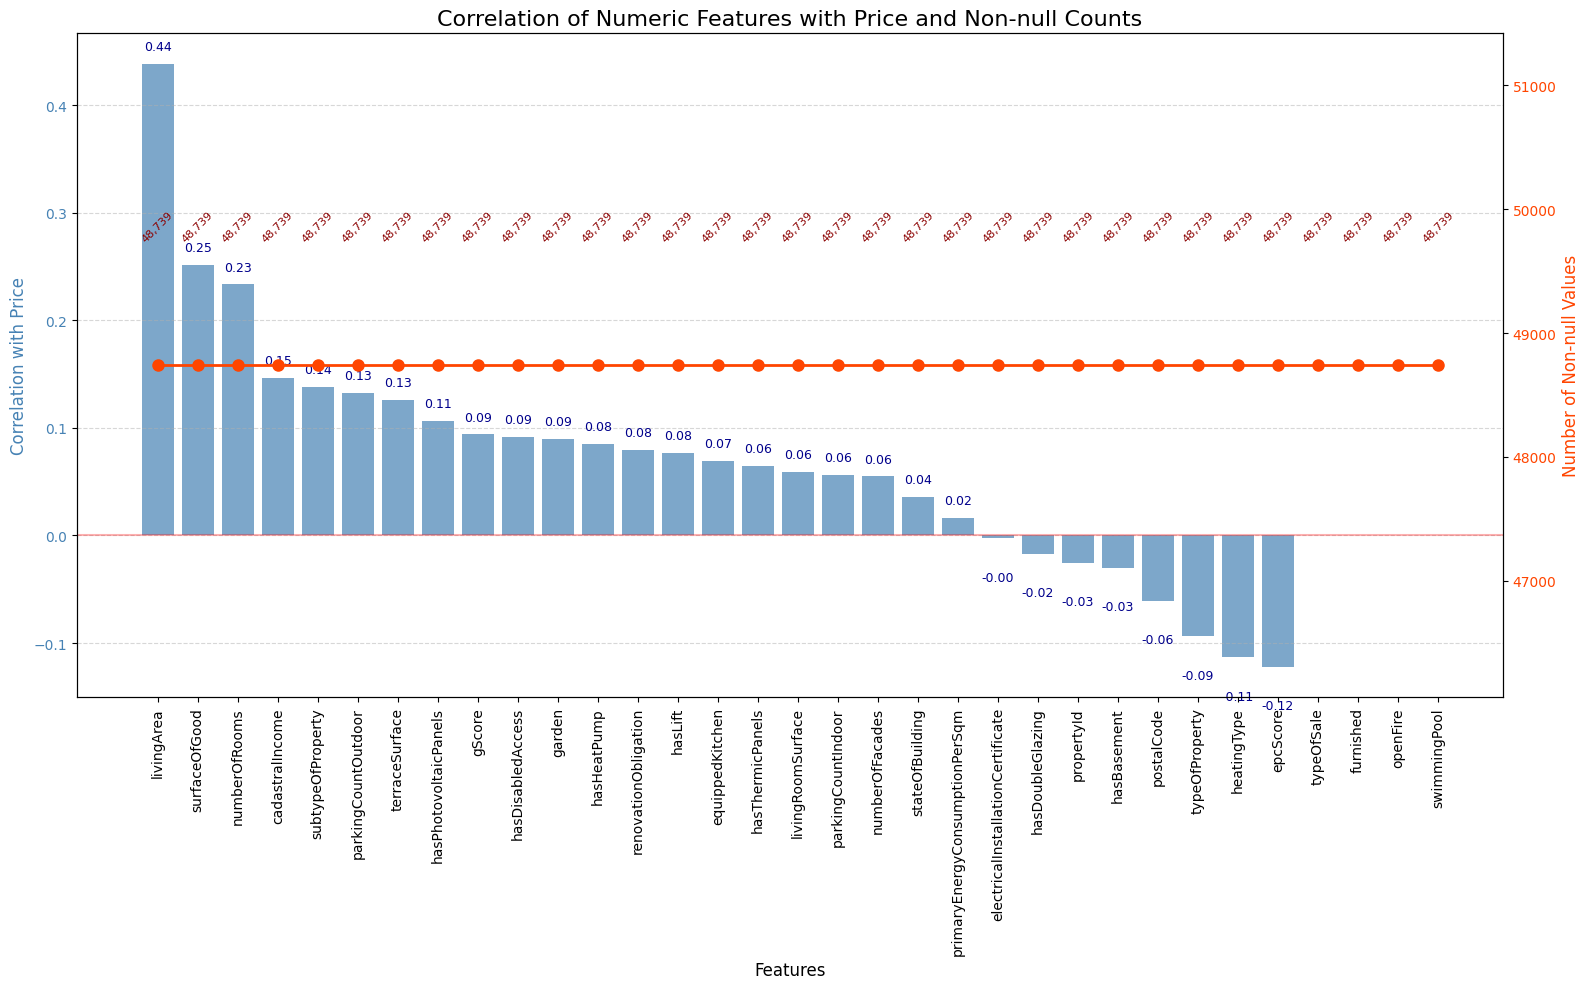

In [3]:
# Select only numeric columns from the dataframe
from matplotlib import pyplot as plt


numeric_columns = df.select_dtypes(include=['float64', 'int64']).columns

# Create a dictionary to store correlations with price and non-null counts
price_correlations = {}
notna_counts = {}

# Calculate correlation of each numeric column with price and count non-null values
for column in numeric_columns:
    if column != 'price' and column != 'id':  # Exclude price itself and id
        correlation = df[column].corr(df['price'])
        price_correlations[column] = correlation
        notna_counts[column] = df[column].notna().sum()

# Convert to Series for easier plotting
price_corr_series = pd.Series(price_correlations).sort_values(ascending=False)
notna_count_series = pd.Series({k: notna_counts[k] for k in price_corr_series.index})

# Create a figure with two y-axes
fig, ax1 = plt.subplots(figsize=(16, 10))
ax2 = ax1.twinx()

# Create a bar chart for correlations
bars = ax1.bar(price_corr_series.index, price_corr_series.values, color='steelblue', alpha=0.7)

# Add correlation values on top of the bars
for bar in bars:
    height = bar.get_height()
    ax1.text(
        bar.get_x() + bar.get_width() / 2.,
        height + 0.01 if height >= 0 else height - 0.03,
        f'{height:.2f}',
        ha='center', va='bottom' if height >= 0 else 'top',
        fontsize=9, color='darkblue'
    )

# Create a line plot for non-null counts
ax2.plot(price_corr_series.index, notna_count_series.values, 'o-', color='orangered', linewidth=2, markersize=8)

# Add count labels above the line points
for i, count in enumerate(notna_count_series.values):
    ax2.text(i, count + 1000, f'{count:,}', ha='center', rotation=45, fontsize=8, color='darkred')

# Customize the plot
ax1.set_title('Correlation of Numeric Features with Price and Non-null Counts', fontsize=16)
ax1.set_xlabel('Features', fontsize=12)
ax1.set_ylabel('Correlation with Price', color='steelblue', fontsize=12)
ax2.set_ylabel('Number of Non-null Values', color='orangered', fontsize=12)
ax1.tick_params(axis='y', labelcolor='steelblue')
ax2.tick_params(axis='y', labelcolor='orangered')
ax1.set_xticks(range(len(price_corr_series.index)))
ax1.set_xticklabels(price_corr_series.index, rotation=90)
ax1.axhline(y=0, color='r', linestyle='-', alpha=0.3)
ax1.grid(axis='y', linestyle='--', alpha=0.5)

plt.tight_layout()
plt.show()

Get relevant features 

In [4]:
# Calculate the correlation matrix, excluding propertyId
correlation_matrix = df.drop(columns=['propertyId']).corr()
price_correlations = correlation_matrix['price'].abs().sort_values(ascending=False)

features = price_correlations[price_correlations > 0.03].index.tolist() #list top correlated features 
features = features[1:] # remove price from the list of features

# features = df.drop(columns=['price', 'propertyId']).columns.tolist() # remove price and propertyId from the list of features

features

['livingArea',
 'surfaceOfGood',
 'numberOfRooms',
 'cadastralIncome',
 'subtypeOfProperty',
 'parkingCountOutdoor',
 'terraceSurface',
 'epcScore',
 'heatingType',
 'hasPhotovoltaicPanels',
 'gScore',
 'typeOfProperty',
 'hasDisabledAccess',
 'garden',
 'hasHeatPump',
 'renovationObligation',
 'hasLift',
 'equippedKitchen',
 'hasThermicPanels',
 'postalCode',
 'livingRoomSurface',
 'parkingCountIndoor',
 'numberOfFacades',
 'stateOfBuilding',
 'hasBasement']

Prepare for regression + Standardize scales

In [5]:
target = 'price'

x = df[features]
y = df[target]

# Split the dataset
X_train, X_test, y_train, y_test = train_test_split(x, y, test_size=0.2, random_state=42)

# Scale features
# scaler = StandardScaler()
# X_train_scaled = scaler.fit_transform(X_train)
# X_test_scaled = scaler.transform(X_test)

---
## Option 1: Linear Regression Coefficients (for linear relationships)

<Axes: title={'center': 'Linear Regression Feature Importance'}>

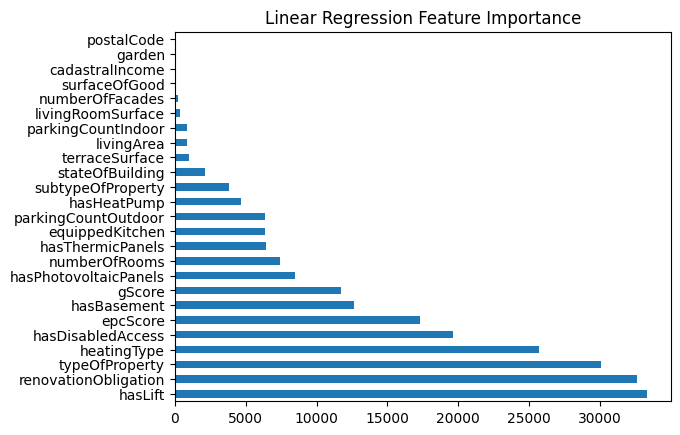

In [6]:
lr = LinearRegression()
lr.fit(X_train, y_train)

# Get importance from coefficients (absolute values give relative importance)
importance = pd.Series(np.abs(lr.coef_), index=features)
importance.sort_values(ascending=False).plot(kind='barh', title='Linear Regression Feature Importance')

## Evaluate Model

In [7]:
y_pred = lr.predict(X_test)
print("RMSE:", root_mean_squared_error(y_test, y_pred))
print("R² Score:", r2_score(y_test, y_pred))
print("MAE:", np.mean(np.abs(y_test - y_pred)))
print("MAPE:", np.mean(np.abs((y_test - y_pred) / y_test)) * 100, "%")

RMSE: 194574.35378214708
R² Score: 0.308100418650772
MAE: 124234.0803959254
MAPE: 40.35049075472264 %


---

## Option 2: Random Forest Feature Importance (handles non-linear relationships)

<Axes: title={'center': 'Random Forest Feature Importance'}>

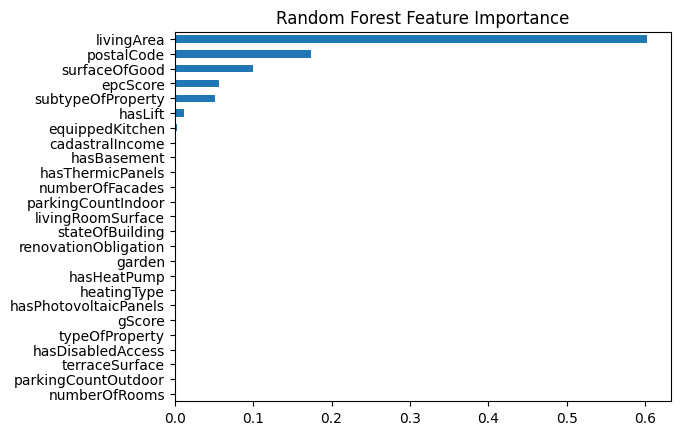

In [8]:
rf = RandomForestRegressor(n_estimators=100, max_depth=3, min_samples_leaf=5, random_state=42)
rf.fit(X_train, y_train)

# Get feature importances
importance = pd.Series(rf.feature_importances_, index=features)
importance.sort_values(ascending=True).plot(kind='barh', title='Random Forest Feature Importance')

### Evaluate Model

In [9]:
y_pred = rf.predict(X_test)
print("RMSE:", root_mean_squared_error(y_test, y_pred))
print("R² Score:", r2_score(y_test, y_pred))
print("MAPE:", np.mean(np.abs((y_test - y_pred) / y_test)) * 100, "%")

RMSE: 192256.8560518616
R² Score: 0.3244841454647839
MAPE: 42.90299803904193 %


---

## Option 3: XGBoost
XGBoost (eXtreme Gradient Boosting) is another powerful ensemble learning technique that often outperforms both linear regression and random forest models. It uses gradient boosting with regularization to reduce overfitting and improve performance.

Key advantages of XGBoost:
- High performance and efficient computation
- Regularization to prevent overfitting
- Handles missing values automatically
- Supports parallel processing
- Offers built-in cross-validation

For our housing price prediction task, XGBoost can capture complex non-linear relationships while maintaining good generalization performance.

<Axes: title={'center': 'XGBoost Feature Importance'}>

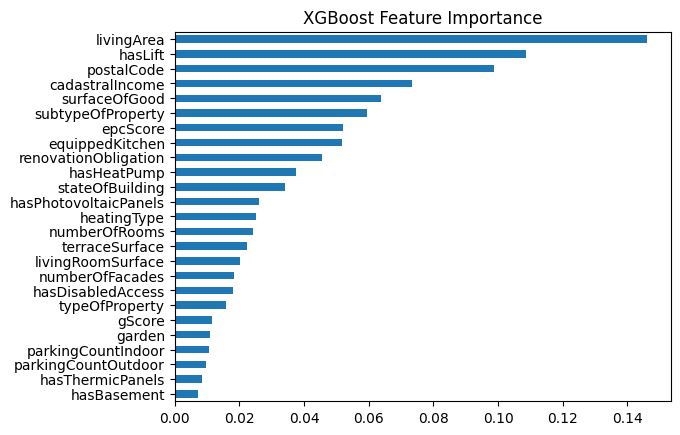

In [10]:

# Initialize XGBoost model with good default parameters
xgb_model = xgb.XGBRegressor(
    n_estimators=100,
    learning_rate=0.1,
    max_depth=5,
    min_child_weight=1,
    subsample=0.8,
    colsample_bytree=0.8,
    objective='reg:squarederror',
    random_state=42
)

# Train the model
xgb_model.fit(X_train, y_train)

# Get feature importance
importance = pd.Series(xgb_model.feature_importances_, index=features)
importance.sort_values(ascending=True).plot(
    kind='barh', 
    title='XGBoost Feature Importance'
)

In [11]:
y_pred = xgb_model.predict(X_test)

# Evaluate the model
print("XGBoost Performance Metrics:")
print("RMSE:", root_mean_squared_error(y_test, y_pred))
print("R² Score:", r2_score(y_test, y_pred))
print("MAPE:", mean_absolute_percentage_error(y_test, y_pred) * 100, "%")
print("MAE:", mean_absolute_error(y_test, y_pred))

XGBoost Performance Metrics:
RMSE: 116381.5390625
R² Score: 0.7524630427360535
MAPE: 21.181388199329376 %
MAE: 71511.421875
